# 06-Cognitive Memory Architectures

In Lesson 05, we engineered a cyclic StateGraph capable of autonomous self-correction. We built an AI that could loop backwards, rewrite its own code, and mathematically evaluate its success.

However, all of our graphs thus far have suffered from **Amnesia**. They are completely stateless between executions. If you run the graph, it completes its task and terminates. If you immediately ask it a follow-up question, the state tensor is re-initialized to zero. It has absolutely no recollection of the previous execution.

To build persistent, user-facing AI (like ChatGPT or an enterprise customer service agent), we must introduce **Cognitive Memory Architectures**. We must map the episodic state of the agent to persistent storage using **Checkpointers** and **Thread-Level Isolation**.

Let's set up our environment to engineer physical memory persistence.

In [1]:
# Required installations: pip install langchain langchain-core langchain-ollama langgraph matplotlib seaborn
from typing import TypedDict, Annotated
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import MemorySaver
from langchain_core.messages import HumanMessage, SystemMessage
from langchain_ollama import ChatOllama
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns

# Set professional visualization styling
sns.set_theme(style="whitegrid")

print("✅ Systems Architecture & Cognitive Memory Environment Ready.")

✅ Systems Architecture & Cognitive Memory Environment Ready.


# 1. The Mathematics of Thread-Level Isolation

In a stateless LangGraph, the execution resolves as $S_{t+1} = S_t \oplus N(S_t)$. When the graph hits `END`, $S_{final}$ is returned and then physically destroyed in RAM.

To build cognitive memory, we introduce a **Checkpointer Function** $\mathcal{C}$ and a unique **Thread Identifier** $\tau$. A thread $\tau$ represents a strict geometric boundary containing the isolated episodic history of a specific user or specific task.

Before a graph initiates, it requests the state from the checkpointer database:


$$S_0(\tau) = \mathcal{C}_{read}(\tau)$$

At every individual step $t$ during the graph's execution, the system mathematically persists the state delta to disk (or in-memory cache):


$$\mathcal{C}_{write}(\tau, t, S_t)$$

This architecture prevents **Context Bleed**. If User A tells the agent *"My secret code is 994"*, this delta is written strictly to $\tau_A$. If User B ($\tau_B$) immediately asks the agent *"What is the secret code?"*, the graph initializes $S_0(\tau_B)$. Because $S_0(\tau_B) \cap S(\tau_A) = \emptyset$, it is mathematically impossible for User B to access User A's data.

# 2. Architecting the Persistent Memory Graph

Let's build a real, persistent conversational agent. We will:

1. Define a State with a dedicated `add_messages` reducer to preserve conversational history.
2. Compile the StateGraph using LangGraph's physical `MemorySaver` checkpointer.
3. Execute sequential interactions across isolated mathematical threads to prove context boundaries.

In [2]:
# --- 🧠 The Cognitive Memory Engine ---

# 1. Define the Mathematical State
class MemoryState(TypedDict):
    # The 'add_messages' reducer is mathematically critical. 
    # It ensures that new messages are APPENDED to the history, not overwritten.
    messages: Annotated[list, add_messages]

# 2. Initialize the Local Policy Network
print("--- 🔌 Initializing Llama 3.2 ---")
llm = ChatOllama(model="llama3.2", temperature=0.7)

# 3. Define the Conversational Node
def chat_node(state: MemoryState) -> dict:
    """Reads the entire accumulated message history and generates the next response."""
    print("   🧠 [NODE: Policy Network] Reading episodic history and generating response...")
    
    # We pass the ENTIRE list of historical messages to the LLM
    response = llm.invoke(state["messages"])
    
    # We return the delta. LangGraph will append this AIMessage to the list.
    return {"messages": [response]}

# 4. Architect the Graph Topology with Checkpointing
print("--- 🏗️ Compiling the Persistent StateGraph ---")
workflow = StateGraph(MemoryState)
workflow.add_node("Chatbot", chat_node)
workflow.add_edge(START, "Chatbot")
workflow.add_edge("Chatbot", END)

# Initialize the physical Checkpointer (in-memory SQLite equivalent)
memory_checkpointer = MemorySaver()

# Compile the graph, injecting the Checkpointer into the runtime
app = workflow.compile(checkpointer=memory_checkpointer)

# 5. Execute Thread-Isolated Cognitive Physics
print("\n--- 🚀 Initiating Thread-Isolated Execution ---")

# --- THREAD A: User 1 Interaction ---
thread_config_A = {"configurable": {"thread_id": "thread_alpha_99"}}

print("\n👤 [User A]: 'Hi, my name is Dr. Aris and my access code is 77X-Omega.'")
app.invoke(
    {"messages": [HumanMessage(content="Hi, my name is Dr. Aris and my access code is 77X-Omega.")]},
    config=thread_config_A
)

# --- THREAD B: User 2 Interaction (Context Bleed Test) ---
# We switch to a completely different mathematical thread.
thread_config_B = {"configurable": {"thread_id": "thread_beta_42"}}

print("\n👤 [User B]: 'What is my name and access code?'")
response_b = app.invoke(
    {"messages": [HumanMessage(content="What is my name and access code?")]},
    config=thread_config_B
)
print(f"🤖 [Agent to User B]: {response_b['messages'][-1].content}")
# Notice the agent refuses to answer or says it doesn't know. The threads are isolated!

# --- THREAD A: User 1 Follow-Up (Episodic Recall Test) ---
# We switch BACK to Thread A. The agent should retrieve the saved state from disk.
print("\n👤 [User A]: 'I forgot my code. Can you remind me what it is?'")
response_a2 = app.invoke(
    {"messages": [HumanMessage(content="I forgot my code. Can you remind me what it is?")]},
    config=thread_config_A
)
print(f"🤖 [Agent to User A]: {response_a2['messages'][-1].content}")

print("\n--- 💡 Engineering Insight ---")
print("Look closely at the execution output. When we pinged Thread B, the LLM had no idea what the code was, proving our mathematical security boundaries hold. When we switched back to Thread A and asked for the code without providing it, the checkpointer flawlessly pulled the historical `messages` tensor from the SQLite cache, injected it into the prompt, and the LLM correctly recalled '77X-Omega'.")

--- 🔌 Initializing Llama 3.2 ---
--- 🏗️ Compiling the Persistent StateGraph ---

--- 🚀 Initiating Thread-Isolated Execution ---

👤 [User A]: 'Hi, my name is Dr. Aris and my access code is 77X-Omega.'
   🧠 [NODE: Policy Network] Reading episodic history and generating response...

👤 [User B]: 'What is my name and access code?'
   🧠 [NODE: Policy Network] Reading episodic history and generating response...
🤖 [Agent to User B]: I don't have any information about you, including your name or access code. I'm a large language model, I don't retain any user data or have the ability to store personal information. Each time you interact with me, it's a new conversation and I don't have any prior knowledge about you.

If you're trying to access a specific account or system, I recommend contacting the administrator or support team associated with that system for assistance.

👤 [User A]: 'I forgot my code. Can you remind me what it is?'
   🧠 [NODE: Policy Network] Reading episodic history and gene

# 3. Visualizing Cognitive Memory Topography

To understand the architecture of state persistence, we must visualize how the **Graph Runtime** (the CPU/GPU computing the LLM) interfaces with the **Checkpointer Storage** (the Database) across the axis of time.

/tmp/ipykernel_20035/580525470.py:8: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  db_box = patches.Rectangle((0, 0), 12, 2.5, fill=True, color='#bdc3c7', alpha=0.3, linewidth=2, edgecolor='black')
/tmp/ipykernel_20035/580525470.py:14: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  thread_a_box = patches.Rectangle((1, 0.2), 4, 2.1, fill=True, color='#3498db', alpha=0.2, linewidth=2, edgecolor='#2980b9')
/tmp/ipykernel_20035/580525470.py:20: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  thread_b_box = patches.Rectangle((7, 0.2), 4, 2.1, fill=True, color='#e74c3c', alpha=0.2, linewidth=2, edgecolor='#c0392b')
/tmp/ipykernel_20035/580525470.py:26: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  rt_box = patches.Rectangle((0, 4.5), 12, 3, fill=True, color='#f1c40f', alpha=0.1, linewidth=2, ed

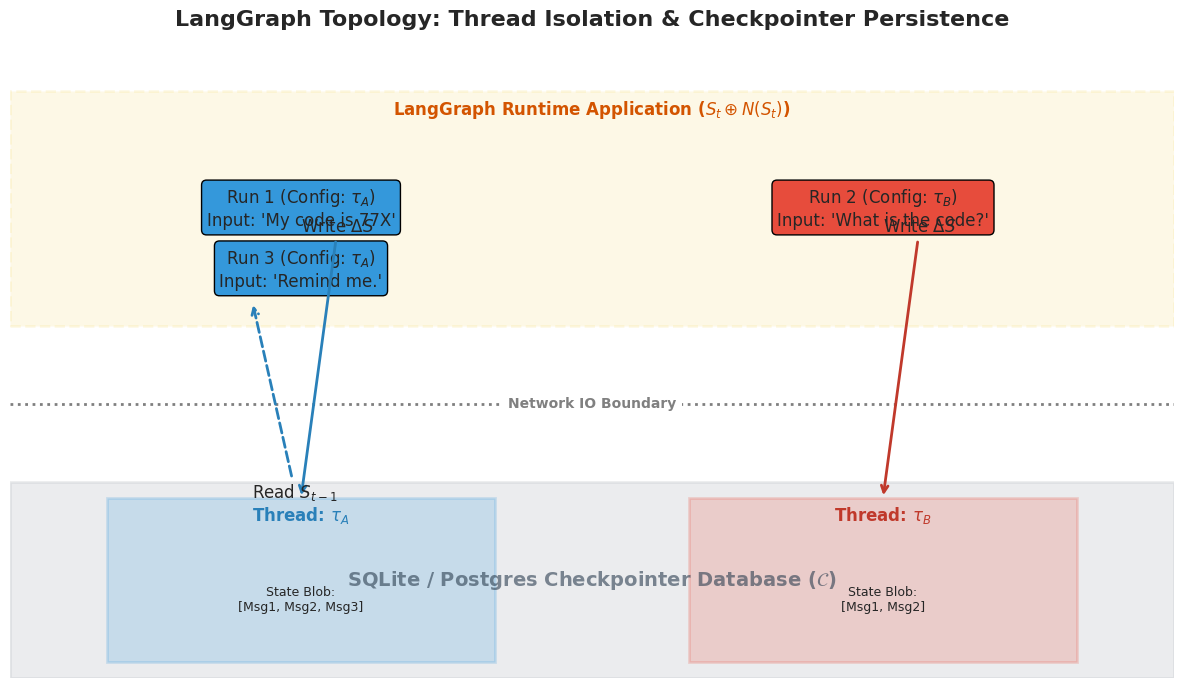

In [8]:
# Visualizing Cognitive Memory and Thread Isolation
fig, ax = plt.subplots(figsize=(12, 7))
fig.suptitle("LangGraph Topology: Thread Isolation & Checkpointer Persistence", fontsize=16, fontweight='bold')

ax.axis('off')

# 1. Define the Storage Layer (The Database)
db_box = patches.Rectangle((0, 0), 12, 2.5, fill=True, color='#bdc3c7', alpha=0.3, linewidth=2, edgecolor='black')
ax.add_patch(db_box)
ax.text(6, 1.25, "SQLite / Postgres Checkpointer Database ($\\mathcal{C}$)", 
        ha='center', va='center', fontweight='bold', fontsize=14, color='#2c3e50', alpha=0.6)

# Thread A Storage Boundary
thread_a_box = patches.Rectangle((1, 0.2), 4, 2.1, fill=True, color='#3498db', alpha=0.2, linewidth=2, edgecolor='#2980b9')
ax.add_patch(thread_a_box)
ax.text(3, 2, "Thread: $\\tau_A$", ha='center', fontweight='bold', color='#2980b9')
ax.text(3, 1, "State Blob:\n[Msg1, Msg2, Msg3]", ha='center', va='center', fontsize=9)

# Thread B Storage Boundary
thread_b_box = patches.Rectangle((7, 0.2), 4, 2.1, fill=True, color='#e74c3c', alpha=0.2, linewidth=2, edgecolor='#c0392b')
ax.add_patch(thread_b_box)
ax.text(9, 2, "Thread: $\\tau_B$", ha='center', fontweight='bold', color='#c0392b')
ax.text(9, 1, "State Blob:\n[Msg1, Msg2]", ha='center', va='center', fontsize=9)

# 2. Define the Runtime Layer (The Execution Graph)
rt_box = patches.Rectangle((0, 4.5), 12, 3, fill=True, color='#f1c40f', alpha=0.1, linewidth=2, edgecolor='#f39c12', linestyle='--')
ax.add_patch(rt_box)
ax.text(6, 7.2, "LangGraph Runtime Application ($S_t \\oplus N(S_t)$)", ha='center', fontweight='bold', fontsize=12, color='#d35400')

# Runtime Nodes
ax.text(3, 6, "Run 1 (Config: $\\tau_A$)\nInput: 'My code is 77X'", ha='center', va='center', bbox=dict(boxstyle="round,pad=0.3", fc="#3498db", ec="black"))
ax.text(9, 6, "Run 2 (Config: $\\tau_B$)\nInput: 'What is the code?'", ha='center', va='center', bbox=dict(boxstyle="round,pad=0.3", fc="#e74c3c", ec="black"))
ax.text(3, 5, "Run 3 (Config: $\\tau_A$)\nInput: 'Remind me.'", ha='center',bbox=dict(boxstyle="round,pad=0.3", fc="#3498db", ec="black"))

# 3. Draw the Read/Write IO Operations
# Run 1 Writes to Thread A
ax.annotate("Write $\\Delta S$", xy=(3, 2.3), xytext=(3, 5.7), arrowprops=dict(arrowstyle="->", color="#2980b9", lw=2, linestyle='solid'))
# Run 2 Writes to Thread B
ax.annotate("Write $\\Delta S$", xy=(9, 2.3), xytext=(9, 5.7), arrowprops=dict(arrowstyle="->", color="#c0392b", lw=2, linestyle='solid'))
# Run 3 Reads from Thread A
ax.annotate("Read $S_{t-1}$", xy=(2.5, 4.8), xytext=(2.5, 2.3), arrowprops=dict(arrowstyle="->", color="#2980b9", lw=2, linestyle='dashed'))

# Air gap line
ax.axhline(y=3.5, color='black', linestyle=':', linewidth=2, alpha=0.5)
ax.text(6, 3.5, "Network IO Boundary", ha='center', va='center', bbox=dict(fc="white", ec="none"), fontsize=10, fontweight='bold', color='gray')

plt.xlim(0, 12)
plt.ylim(0, 8)
plt.tight_layout()
plt.show()

## Real-World Use Case or Analogy:

Think of Thread-Isolated Checkpointing like **A Doctor Working in a Massive Hospital**:

* **The LangGraph Runtime (The Doctor)**: The doctor is the logic engine. They are highly intelligent, can prescribe medicine (call tools), and can generate diagnoses (run LLM inference). However, the doctor sees 50 patients a day. If they relied purely on their biological short-term memory (a stateless graph), they would accidentally give Patient B the medicine intended for Patient A.
* **The Threads (The Patient ID)**: Every patient who walks into the hospital receives a unique wristband (`thread_id="patient_99"`).
* **The Checkpointer (The Medical Archives)**: When the doctor enters Patient A's room, they do not start from scratch. They pull the physical chart attached to `patient_99` from the database. They read the episodic history ($\mathcal{C}_{read}$). They talk to the patient, make a new observation, write it at the bottom of the chart ($\Delta S$), and slot the chart back into the filing cabinet ($\mathcal{C}_{write}$).

By strictly attaching computation to unique thread IDs, an Enterprise AI system can serve 10,000 parallel user sessions simultaneously with a single, central LangGraph application, completely eliminating context bleed while providing perfect episodic recall.